In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import os
os.environ["PYTHONUTF8"] = "1"
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Reszta importów...
sys.path.append(os.path.abspath('../pipeline'))
from grid import Grid
from solver import Solver


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


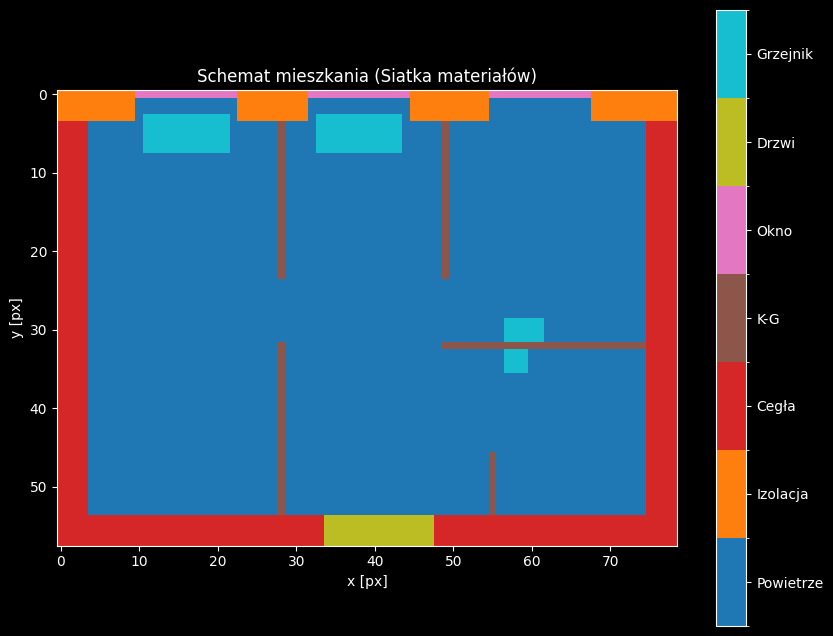

,ID,Nazwa,Lambda [W/mK],Alfa (Dyfuzyjność)
0,0,Air,0.025,2.500000e-04
1,1,Wall_Insul,0.030,5.000000e-07
2,2,Wall_Brick,0.500,4.400000e-07
3,3,Drywall,0.170,8.000000e-08
4,4,Window,0.800,4.000000e-07
5,5,Door,0.200,4.000000e-07
6,6,Heater,50.000,2.500000e-04


In [6]:

grid = Grid(config_path='data/config.json')

solver = Solver(grid)

labels = ['Powietrze', 'Izolacja', 'Cegła', 'K-G', 'Okno', 'Drzwi', 'Grzejnik']
num_materials = len(labels)

cmap = plt.get_cmap('tab10', num_materials)

bounds = np.arange(-0.5, num_materials + 0.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)


plt.figure(figsize=(10, 8))

img = plt.imshow(grid.material_grid, cmap=cmap, norm=norm, origin='upper', aspect='equal')

plt.title("Schemat mieszkania (Siatka materiałów)")
plt.xlabel("x [px]")
plt.ylabel("y [px]")


cbar = plt.colorbar(img, ticks=np.arange(num_materials))
cbar.ax.set_yticklabels(labels)

plt.show()

materials = grid.config['materials']
data = []

for key, val in materials.items():
    data.append({
        "ID": key,
        "Nazwa": val['name'],
        "Lambda [W/mK]": val['lambda'],
        "Alfa (Dyfuzyjność)": val['alpha']
    })

df = pd.DataFrame(data)

display(df)
